# **Step2. Multi-label 분류**



**미션 : 리뷰에 포함된 11가지 속성을 검출하기(Multi-label Multi-Classification)**

1) 목표 : 리뷰 내용에서, 속성에 해당하는 내용이 등장하는지 분류하는
모델 생성
2) 절차
    * 데이터 전처리 : 주어진 데이터를 목표에 맞는 형태로 변환
    * 모델링 : 다중 레이블 분류 파인 튜닝
        * 일반 파인 튜닝
        * LoRA 파인 튜닝

## 1.환경준비

### (1) 라이브러리 설치 및 로딩

In [ ]:
!pip install datasets peft accelerate -q

In [ ]:
# 한글폰트 설치
import matplotlib as mpl
import matplotlib.font_manager as fm

%config InlineBackend.figure_format = 'retina'
!apt -qq -y install fonts-nanum

font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fontprop = fm.FontProperties(fname=font_path)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import torch

from transformers import Trainer, TrainingArguments, EarlyStoppingCallback, AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import LabelEncoder

from peft import get_peft_model, LoraConfig, TaskType

import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

c:\Users\USER\anaconda3\envs\aivle_pytorch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### (2) GPU 설정
* GPU 사용을 위한 설정

In [3]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 2.데이터 준비

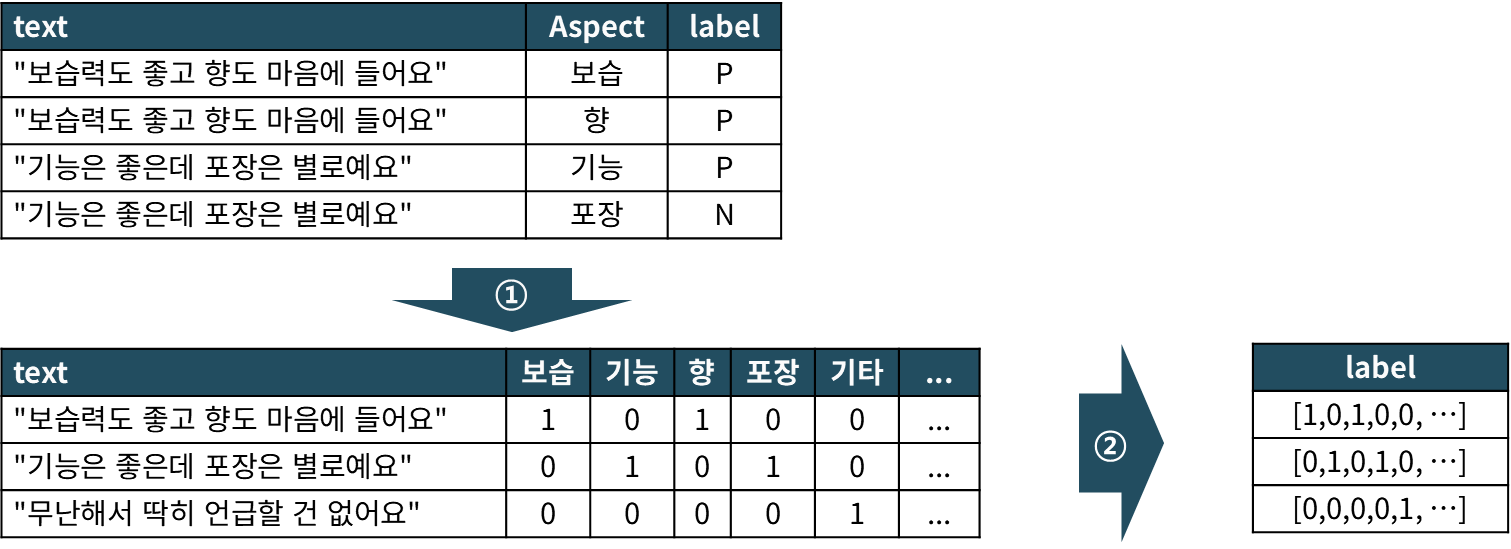

### (1) 데이터 로딩
* data.csv 파일 로딩

In [ ]:
# 파일 업로드
from google.colab import files
uploaded = files.upload()

### (2) Dataset 준비1

In [ ]:
# 레이블 리스트
labels = ['보습', '기능', '밀착', '가격', '향', '편의성', '기타', '외형', '포장', '품질', '피부']

* multi-hot label 만들기
    * multi-hot label 값이 문자열이 아닌 리스트여야 합니다.
* multi-hot label을 추가한 데이터셋을 data1 으로 저장합니다.

* 검증 : 제대로 생성되었는지 다음 코드로 검증해 봅니다.

In [ ]:
review = "(장점 ) 1.쓰기편하고 제형이 묽어서 발림성 좋다. 2.백탁없다 (단점)"
display(data[data['text'].str.startswith(review)])
display(data1[data1['text'].str.startswith(review)])

* 전체 데이터에서 10000건을 샘플링 합니다.(파인튜닝 시간 절약을 위해서)

### (3) Dataset 준비2
* train, val 분할 7:3
* 텐서 데이터셋

In [ ]:
# train, val 분할 7:3


In [ ]:
# df로 부터 텐서 데이터셋 만들기


### (4) 토크나이징

* 다중 레이블 분류 문제에서 label은 float 타입이어야 함

In [ ]:
# 토크나이저 다운로드


In [ ]:
# 전처리 함수 정의 : label을 float 타입으로 변환 포함


# 전처리 적용



## 3.Fine-Tuning1
* 일반 파인 튜닝으로

### (1) 사전학습 모델 준비
* problem_type="multi_label_classification"

In [ ]:
# label(클래스) 수 지정


# 모델 준비 : 옵션 problem_type="multi_label_classification" 추가



### (2) 학습 설정

* TrainArguments

* Trainer

In [ ]:
# 학습 시 추가 함수 준비
from torch.utils.data import DataLoader
from transformers import default_data_collator

# 평가함수(선택 사항)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))  # sigmoid
    preds = (probs > 0.5).astype(int)
    return {
        "weighted_f1": f1_score(labels, preds, average="weighted"),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

# 사용자 정의 data_collator(필수 사항)
def float_label_collator(features):
    batch = default_data_collator(features)
    batch["labels"] = batch["labels"].float()
    return batch

In [ ]:
# Trainer 설정 :
trainer = Trainer(


    data_collator=float_label_collator,  # 필수사항
    compute_metrics=compute_metrics,     # 선택사항


)

### (3) 학습
* 7000건 학습데이터에 대해서, 학습 시간이 10~13분 정도 소요 됩니다.

### (4) 모델 검증평가

* 예측값

* 실제값

* 평가

## 4.Fine-Tuning2
* LoRA 튜닝하기

### (1) 사전학습 모델 준비
* problem_type="multi_label_classification"

### (2) LoRA 구성

In [ ]:
# LoRA 구성 정의



# LoRA 적용




### (3) 학습 설정

* TrainArguments
    * 일반 파인 튜닝보다는 학습률을 조금 높게 설정

* Trainer

In [ ]:
# 사용자 정의 data_collator 생
from torch.utils.data import DataLoader
from transformers import default_data_collator

def float_label_collator(features):
    batch = default_data_collator(features)
    batch["labels"] = batch["labels"].float()
    return batch

In [ ]:
# Trainer 설정


### (4) 학습

### (5) 모델 검증평가